# BarchartRace: Movimiento aéreo neto de pasajeros.

Esta visualización es realizada en base a la información publicada por la [Junta Aeronáutica Civil](https://www.jac.gob.cl/estadisticas/estadisticas-historicas/) de Chile.

## Preparación de los datos.

### Importación

1.- Importamos los paquetes necesarios.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.animation as animation
from IPython.display import HTML

Aquí debes cargar la BBDD de la [Junta Aeronáutica Civil](https://www.jac.gob.cl/estadisticas/estadisticas-historicas/) de Chile.

In [ ]:
from google.colab import files
files.upload()

In [ ]:
raw = pd.DataFrame(pd.read_excel(¡Carga aquí tu BBDD!))

### Depuración de los datos.

1.- Vamos a generar una columna "PASAJEROS_TOTAL" que contenga la suma d los pasajeros liberados ("PAX_LIB") y los regulares ("PASAJEROS").

In [ ]:
raw['PASAJEROS_TOTAL'] = raw['PAX_LIB'] + raw['PASAJEROS']

In [ ]:
raw

,Año,Mes,Cod_Operador,Operador,Grupo,ORIG_1,DEST_1,ORIG_1_N,DEST_1_N,ORIG_1_PAIS,...,DEST_2_PAIS,OPER_2,NAC,PAX_LIB,PASAJEROS,CAR_LIB,CARGA (Ton),CORREO,Distancia,PASAJEROS_TOTAL
0,1984,1,31,FAST AIR,FAST AIR,ARI,NYC,ARICA,NEW YORK,CHILE,...,ESTADOS UNIDOS,SALEN,INTERNACIONAL,0.0,0,0,13.09400,0.0,7369,0.0
1,1984,1,31,FAST AIR,FAST AIR,SCL,BOG,SANTIAGO,BOGOTA,CHILE,...,COLOMBIA,SALEN,INTERNACIONAL,0.0,0,0,29.08600,0.0,4247,0.0
2,1984,1,31,FAST AIR,FAST AIR,SCL,MIA,SANTIAGO,MIAMI,CHILE,...,ESTADOS UNIDOS,SALEN,INTERNACIONAL,0.0,0,0,33.62700,0.0,6653,0.0
3,1984,1,31,FAST AIR,FAST AIR,SCL,PTY,SANTIAGO,CIUDAD DE PANAMÁ,CHILE,...,PANAMA,SALEN,INTERNACIONAL,0.0,0,0,0.00000,0.0,4805,0.0
4,1984,1,31,FAST AIR,FAST AIR,SCL,SAO,SANTIAGO,SAO PAULO,CHILE,...,BRASIL,SALEN,INTERNACIONAL,0.0,0,0,62.00200,0.0,2585,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241464,2024,2,JA,JETSMART,JETSMART,GRU,SCL,SAO PAULO,SANTIAGO,BRASIL,...,BRASIL,LLEGAN,INTERNACIONAL,0.0,0,0,0.35370,0.0,2585,0.0
241465,2024,2,JZ,JETSMART PERÚ,JETSMART,LIM,SCL,LIMA,SANTIAGO,PERU,...,PERU,LLEGAN,INTERNACIONAL,0.0,0,0,6.73600,0.0,2459,0.0
241466,2024,2,JZ,JETSMART PERÚ,JETSMART,SCL,LIM,SANTIAGO,LIMA,CHILE,...,PERU,SALEN,INTERNACIONAL,0.0,0,0,15.69030,0.0,2459,0.0
241467,2024,2,WJ,JETSMART ARGENTINA,JETSMART,SCL,EZE,SANTIAGO,BUENOS AIRES,CHILE,...,ARGENTINA,SALEN,INTERNACIONAL,0.0,0,0,8.12745,0.0,1139,0.0


2.- Para obtener el movimiento neto de pasajeros primero vamos a generar dos bases, una con las entradas y otra con las salidas de pasajeros.

*   **Para la base de salidas** vamos a filtrar todos los vuelos con origen Chile (ORIG_1_PAIS == 'CHILE') y que tengan caracter internacional ('NAC' == 'INTERNACIONAL'). Con esto obtendremos: las ciudades de destino ("DEST_1_N"); el País de destino("DEST_1_PAIS"); el Año del viaje ("Año"); y los Pasajeros totales trasladados ("PASAJEROS_TOTAL").




In [ ]:
salidas_raw = raw[(raw['ORIG_1_PAIS'] == 'CHILE') & (raw['NAC'] == 'INTERNACIONAL') & (raw['OPER_2'] == 'SALEN')][["DEST_1_N", "DEST_1_PAIS", "Año","PASAJEROS_TOTAL"]]

* Para, por año sumar todos los movimientos de pasajeros.

In [ ]:
salidas = pd.DataFrame(salidas_raw.groupby(['DEST_1_N', 'DEST_1_PAIS', 'Año'])['PASAJEROS_TOTAL'].sum())

In [ ]:
salidas = salidas.reset_index() # Resetea el índice.

*   **Para la base de entradas** vamos a filtrar todos los vuelos con destino Chile (DEST_1_PAIS == 'CHILE') y que tengan caracter internacional ('NAC' == 'INTERNACIONAL'). Con esto obtendremos: las ciudades de origen ("ORIG_1_N"); el País de origen ("ORIG_1_PAIS"); el Año del viaje ("Año"); y los Pasajeros totales trasladados ("PASAJEROS_TOTAL").




In [ ]:
entradas_raw = raw[(raw['DEST_1_PAIS'] == 'CHILE') & (raw['NAC'] == 'INTERNACIONAL') & (raw['OPER_2'] == 'LLEGAN')][["ORIG_1_N", "ORIG_1_PAIS", "Año","PASAJEROS_TOTAL"]]

* Para, por año sumar todos los movimientos de pasajeros.

In [ ]:
entradas = pd.DataFrame(entradas_raw.groupby(["ORIG_1_N", "ORIG_1_PAIS", "Año"])['PASAJEROS_TOTAL'].sum())

In [ ]:
entradas = entradas.reset_index() # Resetea el índice.

3.- A continuación, renombraremos las columnas de ambas tablas para facilitar la operación entre ellas.

In [ ]:
salidas = salidas.rename(columns={"DEST_1_N": "name", "DEST_1_PAIS": "group", "Año": "year","PASAJEROS_TOTAL": "salidas"})

In [ ]:
entradas = entradas.rename(columns={"ORIG_1_N": "name", "ORIG_1_PAIS": "group", "Año": "year", "PASAJEROS_TOTAL": "entradas"})

### Operatoria.

1.- Uniremos ambos Dataframe en uno de nombre "neto", diferenciado por columnas las entradas y las salidas de pasajeros.

In [ ]:
neto = pd.merge(entradas, salidas, on=['name', 'group', 'year'])

2.- Para restarle entradas de salidas.

In [ ]:
neto['value'] = neto['entradas'] - neto['salidas']

3.- Eliminaremos las columnas "entradas" y "salidas".

In [ ]:
neto = neto.drop(['entradas','salidas'], axis=1)

4.- Y confirmaremos que no existen valores perdidos en la tabla.

In [ ]:
neto['value'].isnull().values.any()

False

5.- Luego haremos una suma acumulada de los pasajeros por cada ciudad y país según el año. De esta forma nuestro gráfico presentará los valores acumulados desde 1984 hasta 2024, para así visualizar la carrera (BarchartRace).

In [ ]:
neto['cumsum_value'] = neto.groupby(['group', 'name'])['value'].cumsum() # Sumamos de forma acumulada todas las llegadas y creamos una columna.

In [ ]:
neto = neto.drop('value', axis=1) # Eliminamos la columna "value"

In [ ]:
neto = neto.rename(columns={"cumsum_value": "value"}) # Renombramnos la columna de suma acumulada como "value".

6.- Finalmente, haremos un dicionario para asignar a cada país su continente.

In [ ]:
continente = {'ESTADOS UNIDOS': 'América', 'COLOMBIA': 'América', 'PANAMA': 'América', 'BRASIL': 'América', 'ESPAÑA': 'Europa', 'ARGENTINA': 'América', 'FRANCIA': 'Europa', 'PERU': 'América', 'URUGUAY': 'América', 'ITALIA': 'Europa', 'CANADA': 'América', 'ECUADOR': 'América', 'HOLANDA': 'Europa', 'PORTUGAL': 'Europa', 'PARAGUAY': 'América', 'BOLIVIA': 'América', 'ISLA DE TAHITI': 'Asia', 'VENEZUELA': 'América', 'ALEMANIA': 'Europa', 'BELGICA': 'Europa', 'DINAMARCA': 'Europa', 'REINO UNIDO': 'Europa', 'JAPON': 'Asia', 'SUIZA': 'Europa', 'MEXICO': 'América', 'PUERTO RICO': 'América', 'ISRAEL': 'Medio Oriente', 'GUATEMALA': 'América', 'NICARAGUA': 'América', 'COSTA RICA': 'América', 'AUSTRALIA': 'Oceanía', 'REP. POPULAR CHINA': 'Asia', 'REP. DOMINICANA': 'América', 'ANTILLAS HOLANDESA': 'América', 'ISLA DE HAWAI': 'América', 'COSTA DE MARFIL': 'África', 'SUDAFRICA': 'África', 'JAMAICA': 'América', 'NIGERIA': 'África', 'NUEVA ZELANDIA': 'Oceanía', 'ANGOLA': 'África', 'ARUBA': 'América', 'MARRUECOS': 'África', 'LUXEMBURGO': 'Europa', 'CABO VERDE': 'África', 'ANTIGUA': 'América', 'CUBA': 'América', 'SENEGAL': 'África', 'TRINIDAD Y TOBAGO': 'América', 'RUSIA': 'Europa', 'NORUEGA': 'Europa', 'BARBADOS': 'América', 'EL SALVADOR': 'América', 'IRLANDA DEL NORTE': 'Europa', 'SUECIA': 'Europa', 'HONDURAS': 'América', 'TAILANDIA': 'Asia', 'ISLA MARTINICA': 'Oceanía', 'FILIPINAS': 'Asia', 'REP.COREA DEL SUR': 'Asia', 'TAIWAN': 'Asia', 'SINGAPUR': 'Asia', 'MALASIA': 'Asia', 'INDIA': 'Asia', 'HAITI': 'América', 'SURINAM': 'América', 'EMI. ARABES UNIDOS': 'Medio Oriente', 'CHECOESLOVAQUIA': 'Europa', 'TURQUIA': 'Asia', 'BELICE': 'África', 'NAMIBIA': 'África', 'REP. COREA DEL SUR': 'Asia', 'QATAR': 'Medio Oriente', 'EMI.ARABES UNIDOS': 'Medio Oriente', 'ETIOPIA': 'África', 'TOGO': 'África'}
neto = neto.replace({"group": continente})

## Configuración del Barchart.

### Formato de color y etiquetas.

1.- Le asignaremos un color a cada continente mediante un diccionario.

In [ ]:
colores = dict(zip(
    ["América", "Europa", "Asia", "Medio Oriente", "Oceanía", "África", "Antártica"],
    ["#e48381", "#90d595", "#ffb3ff", "#eafb50", "#aafbff", "#f7bb5f", "#adb0ff"]
))

2.- Crearemos otro diccionario con la asignación de continente para cada país.

In [ ]:
group_continente = neto.set_index('name')['group'].to_dict()

3.- A continuación, listaremos los destinos con mayor llegada de pasajeros al 2024. Esto nos dará la posicion final de nuestro gráfico.


In [ ]:
neto[neto['year'].eq(2024)].sort_values(by='value', ascending=True).tail(10)

,name,group,year,value
1058,DALLAS,América,2024,57638.0
1530,LIMA,América,2024,66156.0
1905,MENDOZA,América,2024,67366.0
1448,LA PAZ,América,2024,83856.0
134,ASUNCION,América,2024,120017.0
3053,SAO PAULO,América,2024,159723.0
824,CIUDAD DE PANAMÁ,América,2024,195433.0
405,BOGOTA,América,2024,351592.0
497,BUENOS AIRES,América,2024,421658.0
1954,MIAMI,América,2024,452133.0


4.- Solo por curiosidad, listaremos los destinos con mayor movimiento neto de pasajeros al 2024. Esto lo haremos ordenando la tabla con el valor absoluto (key=abs).

In [ ]:
neto[neto['year'].eq(2024)].sort_values(by='value', key=abs, ascending=True).tail(10)

,name,group,year,value
1448,LA PAZ,América,2024,83856.0
1705,MADRID,Europa,2024,-116928.0
134,ASUNCION,América,2024,120017.0
3053,SAO PAULO,América,2024,159723.0
824,CIUDAD DE PANAMÁ,América,2024,195433.0
2379,PORTO ALEGRE,América,2024,-220144.0
2145,NEW YORK,América,2024,-226794.0
405,BOGOTA,América,2024,351592.0
497,BUENOS AIRES,América,2024,421658.0
1954,MIAMI,América,2024,452133.0


### Presentación del Barchart.

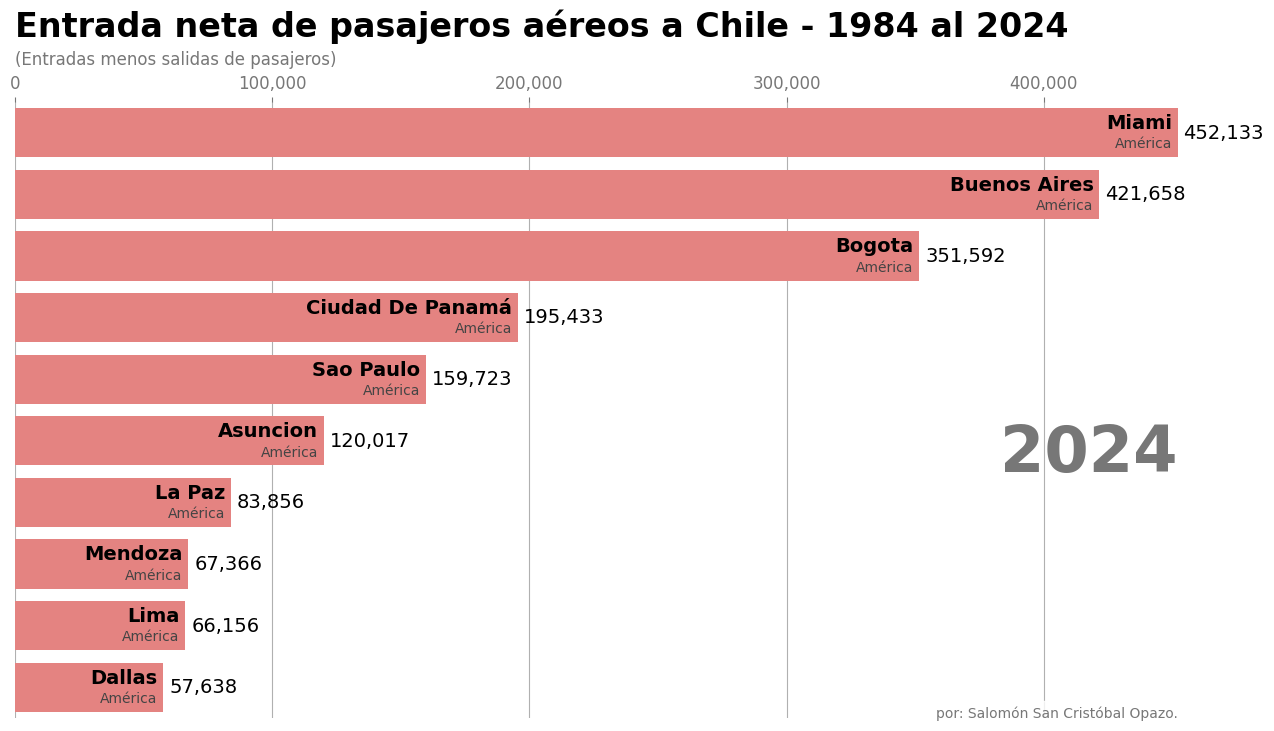

In [ ]:
fig, ax = plt.subplots(figsize=(15, 8))

def draw_barchart(current_year):
    dff = neto[neto['year'].eq(current_year)].sort_values(by='value', ascending=True).tail(10)
    ax.clear()
    ax.barh(dff['name'], dff['value'], color=[colores[group_continente[x]] for x in dff['name']])
    dx = dff['value'].max() / 200
    for i, (value, name) in enumerate(zip(dff['value'], dff['name'])):
        ax.text(value-dx, i,     name.title(),           size=14, weight=600, ha='right', va='bottom')
        ax.text(value-dx, i-.25, group_continente[name], size=10, color='#444444', ha='right', va='baseline')
        ax.text(value+dx, i,     f'{value:,.0f}',  size=14, ha='left',  va='center')
    ax.text(1, 0.4, current_year, transform=ax.transAxes, color='#777777', size=46, ha='right', weight=800)
    ax.text(0, 1.06, '(Entradas menos salidas de pasajeros)', transform=ax.transAxes, size=12, color='#777777')
    ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
    ax.xaxis.set_ticks_position('top')
    ax.tick_params(axis='x', colors='#777777', labelsize=12)
    ax.set_yticks([])
    ax.margins(0, 0.01)
    ax.grid(which='major', axis='x', linestyle='-')
    ax.set_axisbelow(True)
    ax.text(0, 1.15, 'Entrada neta de pasajeros aéreos a Chile - 1984 al 2024',
            transform=ax.transAxes, size=24, weight=600, ha='left', va='top')
    ax.text(1, 0, 'por: Salomón San Cristóbal Opazo.', transform=ax.transAxes, color='#777777', ha='right',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='white'))
    plt.box(False)

draw_barchart(2024)

## Animación del Barchart.

Usaremos la funcion [`FuncAnimation`][FuncAnimation] de la libreria `matplotlib.animation`. Ésta hace una animación llamando repetidamente la función `draw_barchart`.

El argumento `frames` acepta sólo valores enteros para ejecutar la función, aquí usaremos `year` desde 1984 al 2024.

[FuncAnimation]: https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.animation.FuncAnimation.html

In [ ]:
fig, ax = plt.subplots(figsize=(15, 8))
animator = animation.FuncAnimation(fig, draw_barchart, frames=range(1984, 2024+1), interval=300)
HTML(animator.to_jshtml())

Este resultado de la celda es demasiado extenso, por lo que solo se puede mostrar si accedes.


Finalmente, exportaremos la animacion en formato 'mp4' o 'gif'

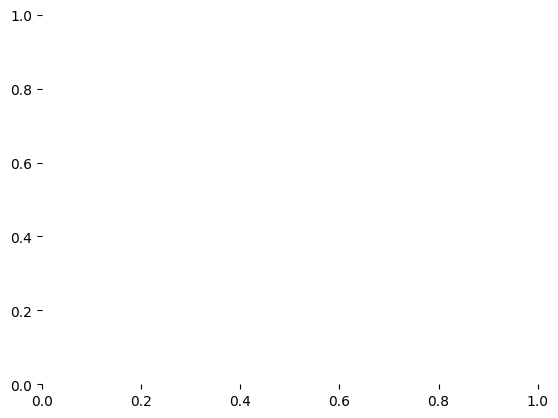

In [ ]:
animator.save('movimiento_neto.gif', writer='pillow')

Gracias por revisar el código, si tiene algún aporte:

[![](https://drive.usercontent.google.com/download?id=1fAEsAjkLzxXKl7t0BQm3kPwgJ9n-aa3d&export=view&authuser=0)](mailto:msancristo@fen.uchile.cl)